# **Paricial Galaxy Zoo // Isabel Nieto y Leonardo Tovar**


### Importación

In [4]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import time
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize, LabelEncoder, StandardScaler
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay
from sklearn.multiclass import OneVsRestClassifier
import matplotlib.pyplot as plt

# Carga de dataset

In [2]:
def cargar_datos(
    carpeta="images_training_rev1",
    archivo_clasificaciones="training_solutions_rev1.csv",
    max_imagenes=60000,
    size=(128, 128)
):
    # 1. Leer archivo CSV con clasificaciones
    df = pd.read_csv(archivo_clasificaciones)
    print(f"Archivo CSV cargado con {len(df)} filas.")

    # Verificar columna identificadora
    if "GalaxyID" not in df.columns:
        raise ValueError("El archivo CSV debe tener una columna 'GalaxyID' que identifique las imágenes.")

    # Crear lista de IDs disponibles
    galaxy_ids = df["GalaxyID"].astype(str).tolist()

    # 2. Listar imágenes disponibles
    archivos = [f for f in os.listdir(carpeta) if f.lower().endswith((".jpg", ".png", ".jpeg"))]

    # Filtrar solo imágenes cuyo GalaxyID exista en el CSV
    archivos_validos = [f for f in archivos if f.split(".")[0] in galaxy_ids]

    # Tomar muestra aleatoria
    if len(archivos_validos) > max_imagenes:
        archivos_validos = random.sample(archivos_validos, max_imagenes)

    print(f"Se seleccionaron {len(archivos_validos)} imágenes aleatorias.")

    # 3. Cargar imágenes y asociarlas con su etiqueta
    X, y = [], []

    for nombre in archivos_validos:
        galaxy_id = nombre.split(".")[0]
        fila = df[df["GalaxyID"] == int(galaxy_id)].iloc[0]
        etiqueta = fila.drop("GalaxyID").idxmax()  # clasificación más probable

        ruta = os.path.join(carpeta, nombre)
        try:
            img = Image.open(ruta).convert("L").resize(size)
            X.append(np.array(img))
            y.append(etiqueta)
        except Exception as e:
            print(f"Error al cargar {nombre}: {e}")

    X = np.array(X)
    print(f"Se cargaron {len(X)} imágenes etiquetadas de '{carpeta}'.")
    return X, y


# Ejemplo de uso
if __name__ == "__main__":
    X, y = cargar_datos(
        carpeta="images_training_rev1",
        archivo_clasificaciones="training_solutions_rev1.csv",
        max_imagenes=12000,
        size=(128, 128)
    )

Archivo CSV cargado con 61578 filas.
Se seleccionaron 12000 imágenes aleatorias.
Se seleccionaron 12000 imágenes aleatorias.
Se cargaron 12000 imágenes etiquetadas de 'images_training_rev1'.
Se cargaron 12000 imágenes etiquetadas de 'images_training_rev1'.


# Exploración inicial del dataset

In [ ]:
print("Forma de X:", X.shape)
print("Etiquetas:", y[:])

### Ver si hay columnas nulas

In [ ]:
df = pd.read_csv("training_solutions_rev1.csv")

# 1) Resumen rápido
print(df.shape)
print(df.dtypes)

# 2) IDs únicos
if "GalaxyID" in df.columns:
    print("IDs únicos:", df["GalaxyID"].is_unique)

# 3) Nulos y proporción
nulls = df.isnull().sum().sort_values(ascending=False)
print("Nulos por columna (>0):")
print(nulls[nulls>0])

# 4) Duplicados
print("Filas duplicadas:", df.duplicated().sum())


A simple vista el dataset está limpio 👍🏻

In [ ]:
# python
from PIL import Image
import os

folder = "images_training_rev1"
ids = pd.read_csv("training_solutions_rev1.csv")["GalaxyID"].astype(str).tolist()

missing = []
bad = []
sizes = {}
channels = {}
for gid in ids:
    p = os.path.join(folder, f"{gid}.jpg")
    if not os.path.exists(p):
        missing.append(gid)
        continue
    try:
        im = Image.open(p)
        sizes.setdefault(im.size, 0)
        sizes[im.size] += 1
        channels.setdefault(im.mode, 0)
        channels[im.mode] += 1
        im.verify()  # detecta corrupciones básicas
    except Exception as e:
        bad.append((gid, str(e)))

print("Archivos faltantes:", len(missing))
print("Archivos corruptos/errores:", len(bad))
print("Tamaños encontrados (muestras):", list(sizes.items())[:5])
print("Modos (canales):", channels)

Las imágenes también están bien al parecer

### ?


Aquí se quiso contar cuantas imagenes se les asigna una clase con mayor probabilidad. Es decir, las únicas clases que predominaron en cada galaxia (que tuvieron una probabilidad mayor). Fueron 5. Las otras, no predominaron en ninguna galaxia. 
Notese que Class 1.3, aparece en 45384 imágenes (73.7% de las 61758), pero solo en 13 imágenes es la clase más probable (0.02%).

In [ ]:
df = pd.read_csv("training_solutions_rev1.csv")
cols = df.drop(columns=["GalaxyID"])
# 1) Número de filas con valor > 0 por columna
col_nonzero = cols.astype(bool).sum().sort_values(ascending=False)

# 2) Suma de probabilidades por columna (total de "peso")
col_sum = cols.sum().sort_values(ascending=False)

# 3) Promedio de probabilidad por columna
col_mean = cols.mean().sort_values(ascending=False)

# 4) Conteo según la columna con mayor probabilidad por fila (argmax)
etiqueta_argmax = cols.idxmax(axis=1)
conteos_argmax = etiqueta_argmax.value_counts().sort_values(ascending=False)

print("Valores > 0 por columna:")
print(col_nonzero)

#print("\nSuma de probabilidades por columna:")
#print(col_sum)

#print("\n==============Promedio de probabilidad por columna:==============")
#print(col_mean)

print("\n==============Conteo por etiqueta (argmax):==============")
print(conteos_argmax)


In [ ]:
# Inspección de las filas donde Class1.3 fue argmax
import pandas as pd
import matplotlib.pyplot as plt

cols = pd.read_csv("training_solutions_rev1.csv").drop(columns=["GalaxyID"])
argmax = cols.idxmax(axis=1)
mask = argmax == "Class1.3"
rows = cols[mask]

print("Número de filas donde Class1.3 es argmax:", len(rows))
print("\nEstadísticas de la columna Class1.3 en esas filas:")
print(rows["Class1.3"].describe())

# ¿Cuántas tienen probabilidad > 0.5 / > 0.33 / > 0.2?
for thr in (0.5, 0.33, 0.2, 0.1):
    print(f"Prob > {thr}: {(rows['Class1.3'] > thr).sum()}")

# Distribución de la probabilidad máxima en esas filas (debería ser igual a Class1.3 porque es argmax)
max_vals = rows.max(axis=1)
print("\nEstadísticas de la probabilidad máxima en esas filas:")
print(max_vals.describe())

# Mostrar top-3 probabilidades por cada una de las filas (útil para ver cuán competitiva es la máxima)
def topk(row, k=3):
    return row.sort_values(ascending=False).head(k)

for i, (idx, row) in enumerate(rows.iterrows()):
    print(f"\nFila {i} (index {idx}) - Class1.3={row['Class1.3']:.3f} - top3: {topk(row).to_dict()}")

# Histograma de las probabilidades de Class1.3 en esas filas
plt.figure(figsize=(6,4))
rows["Class1.3"].hist(bins=10)
plt.title("Distribución de P(Class1.3) en filas donde es argmax")
plt.xlabel("P(Class1.3)")
plt.ylabel("Frecuencia")
plt.show()

Aquí están las 13 fotos con su respectiva probabilidad. De esperar que todas superen el 50%

In [ ]:
# ---------------------------------------------------------
# Vista previa de 10 galaxias aleatorias
# ---------------------------------------------------------
n_muestras = min(10, len(X))
indices = np.random.choice(len(X), n_muestras, replace=False)

plt.figure(figsize=(15, 6))
for i, idx in enumerate(indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[idx], cmap="gray")
    plt.title(y[idx], fontsize=9)
    plt.axis("off")
plt.suptitle("Muestra de 10 galaxias del dataset", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# ---------------------------------------------------------

frecuencias = Counter(y)
clases = list(frecuencias.keys())
conteos = list(frecuencias.values())

# Crear tabla con clases y conteos
tabla_frecuencias = pd.DataFrame({
    "Clase": clases,
    "Frecuencia": conteos
}).sort_values("Frecuencia", ascending=False).reset_index(drop=True)

# ---------------------------------------------------------
# Distribución de frecuencias por clase
# ---------------------------------------------------------

frecuencias = Counter(y)
clases = list(frecuencias.keys())
conteos = list(frecuencias.values())

print("Clases:", clases)
print("Conteos:", conteos)

plt.figure(figsize=(10, 5))
plt.bar(clases, conteos, color="skyblue", edgecolor="black")
plt.title("Distribución de clases (frecuencia por tipo de galaxia)")
plt.xlabel("Clase")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



In [ ]:
df = pd.read_csv("training_solutions_rev1.csv")
cols = df.drop(columns=["GalaxyID"])

plt.figure(figsize=(12,10))
corr = cols.corr(method="spearman")   # Spearman captura monotonicidad
sns.heatmap(corr, cmap="RdBu_r", center=0, vmax=1, vmin=-1)
plt.title("Heatmap: correlación Spearman entre clases")
plt.show()

In [ ]:
promedios = [np.mean(img) for img in X]
df = pd.DataFrame({"clase": y, "brillo": promedios})
plt.figure(figsize=(10, 5))
df.boxplot(column="brillo", by="clase", grid=False, patch_artist=True,
           boxprops=dict(facecolor="lightgray", color="black"),
           medianprops=dict(color="red"))
plt.title("Distribución del brillo por clase")
plt.suptitle("")  # quitar título automático de pandas
plt.xlabel("Clase")
plt.ylabel("Brillo medio")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Entrenamiento de los modelos


### Preparación de datos

In [6]:
#Aplanar imágenes
X_r = np.array([img.flatten() for img in X])
print(f"Forma original: {X[0].shape}, forma aplanada: {X_r.shape}")

# Calcular promedio de brillo por imagen (escala de grises)
promedios_brillo = [np.mean(img) for img in X]
print("Promedio de brillo de las primeras 5 imágenes:", promedios_brillo[:5])

#Codificar etiquetas

le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Ejemplo etiquetas codificadas:", y[:5], "->", y_enc[:5])

# Dividir en conjunto de entrenamiento y prueba (70% / 30%)
X_train, X_test, y_train, y_test = train_test_split(
    X_r, y_enc, test_size=0.3, random_state=40
)
print("Tamaño train:", X_train.shape, "Tamaño test:", X_test.shape)

# Escalar características (media 0, varianza 1)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print("Escalado completado.")

Forma original: (128, 128), forma aplanada: (12000, 16384)
Promedio de brillo de las primeras 5 imágenes: [np.float64(10.5604248046875), np.float64(8.17047119140625), np.float64(10.2244873046875), np.float64(6.5755615234375), np.float64(8.24530029296875)]
Ejemplo etiquetas codificadas: ['Class1.2', 'Class6.2', 'Class1.1', 'Class6.2', 'Class6.2'] -> [1 4 0 4 4]
Tamaño train: (8400, 16384) Tamaño test: (3600, 16384)
Escalado completado.


In [7]:
# Elige el número de componentes principales (por ejemplo, 100)
n_components = 100
pca = PCA(n_components=n_components, random_state=0)
X_train_pca = pca.fit_transform(X_train_s)
X_test_pca = pca.transform(X_test_s)
print(f"PCA aplicado: {X_train_s.shape[1]} -> {X_train_pca.shape[1]} dimensiones")

# Ahora puedes usar X_train_pca y X_test_pca para entrenar modelos más rápidos

PCA aplicado: 16384 -> 100 dimensiones


### 1. Regresion Logistica

In [ ]:
modelo = LogisticRegression(max_iter=1000, solver="lbfgs", multi_class="auto")

print("Entrenando modelo de Regresión Logística...")
modelo.fit(X_train, y_train)

print("✅ Entrenamiento completado.")

In [ ]:
y_pred = modelo.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
cm = confusion_matrix(y_test, y_pred)
print("\nReporte completo por clase:")
print(classification_report(y_test, y_pred))


In [ ]:
acc_lr = accuracy_score(y_test, y_pred)
print(f"Precisión global (accuracy): {acc_lr:.4f}")

# Matriz de confusión
cm_lr = confusion_matrix(y_test, y_pred, labels=modelo.classes_)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=modelo.classes_)

# Mostrar gráfica
disp_lr.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de confusión - Regresión Logística")
plt.show()

### 2. SVM

#### Explicación del código SVM (con PCA)

1. **Definición del modelo**
   - `OneVsRestClassifier(SVC(...))`: Crea un clasificador SVM para cada clase (uno contra el resto), usando kernel RBF (no lineal), con balanceo de clases y probabilidad.

2. **Entrenamiento**
   - `svm_ovr.fit(X_train_pca, y_train)`: Ajusta el modelo usando los datos de entrenamiento ya reducidos por PCA.
   - Se mide el tiempo de entrenamiento para saber cuánto tarda.

3. **Predicción y métricas**
   - `y_pred = svm_ovr.predict(X_test_pca)`: Predice las clases del conjunto de test.
   - Se calcula la exactitud (`accuracy`), el reporte de clasificación (precision, recall, F1 por clase) y se imprime.
   - Se muestra la matriz de confusión como heatmap para ver los aciertos y errores por clase.

4. **ROC-AUC multiclass**
   - Se calcula el ROC-AUC para cada clase usando la probabilidad predicha.
   - Se imprime el AUC por clase y el promedio macro (ignora clases que no aparecen en test).

**Ventajas de este flujo:**
- Usar PCA reduce la dimensionalidad, acelera el entrenamiento y disminuye el riesgo de overfitting.
- El SVM con kernel RBF puede separar clases no lineales.
- El reporte y la matriz de confusión ayudan a interpretar el desempeño por clase.


SVM entrenado en 305.58s
Accuracy SVM: 0.5522
Classification report:
              precision    recall  f1-score   support

           0       0.20      0.26      0.22       322
           1       0.46      0.57      0.51       950
           2       0.00      0.00      0.00         1
           3       0.30      0.16      0.21       206
           4       0.71      0.63      0.67      2121

    accuracy                           0.55      3600
   macro avg       0.33      0.32      0.32      3600
weighted avg       0.57      0.55      0.56      3600

Accuracy SVM: 0.5522
Classification report:
              precision    recall  f1-score   support

           0       0.20      0.26      0.22       322
           1       0.46      0.57      0.51       950
           2       0.00      0.00      0.00         1
           3       0.30      0.16      0.21       206
           4       0.71      0.63      0.67      2121

    accuracy                           0.55      3600
   macro avg      

/home/isabel/Mineria_de_Datos/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/isabel/Mineria_de_Datos/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/isabel/Mineria_de_Datos/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

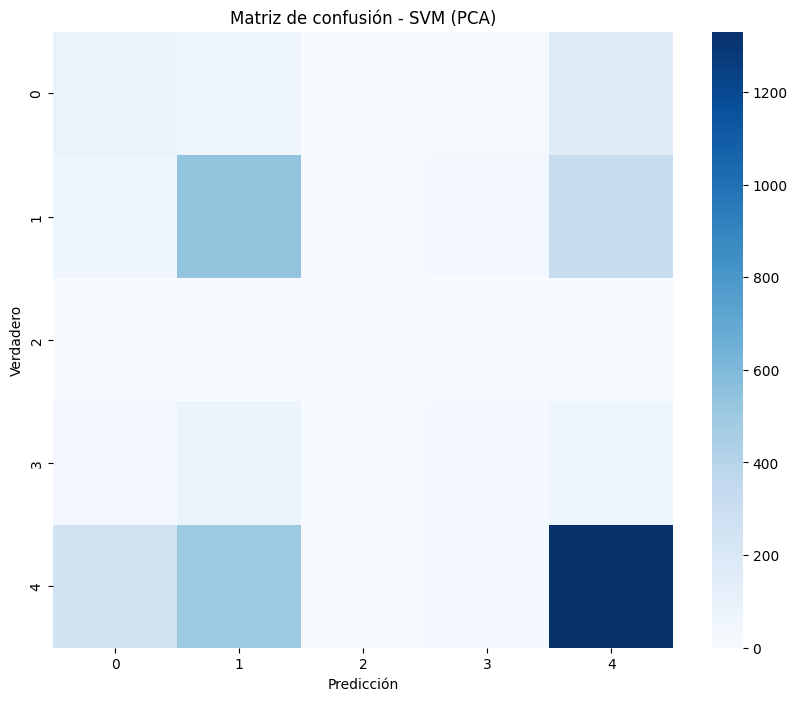

ROC AUC (todas las clases): [0.71  0.74  0.994 0.734 0.687]
ROC AUC macro (promedio ignorando NaN): 0.7731442903749273


In [8]:
# === SVM: preparación, entrenamiento y evaluación con datos reducidos por PCA ===
# Usar los datos transformados por PCA (X_train_pca, X_test_pca) y las etiquetas codificadas (y_train, y_test)

# 1) Definir SVM One-vs-Rest con kernel RBF
svm_ovr = OneVsRestClassifier(SVC(kernel='rbf', C=1.0, probability=True, class_weight='balanced', random_state=0))

# 2) Entrenar y medir tiempo
t0 = time.time()
svm_ovr.fit(X_train_pca, y_train)
train_time = time.time() - t0
print(f"SVM entrenado en {train_time:.2f}s")

# 3) Predicción y métricas
y_pred = svm_ovr.predict(X_test_pca)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy SVM: {acc:.4f}")
print("Classification report:")
print(classification_report(y_test, y_pred))

# Matriz de confusión (absoluta)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap='Blues', fmt='d')
plt.title("Matriz de confusión - SVM (PCA)")
plt.xlabel("Predicción")
plt.ylabel("Verdadero")
plt.show()

# 4) ROC-AUC multiclass (One-vs-Rest)
n_classes = len(np.unique(y_test))
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))
y_score = svm_ovr.predict_proba(X_test_pca)
auc_per_class = []
for i in range(n_classes):
    try:
        auc_per_class.append(roc_auc_score(y_test_bin[:, i], y_score[:, i]))
    except ValueError:
        auc_per_class.append(np.nan)
print("ROC AUC (todas las clases):", np.round(auc_per_class,3))
print("ROC AUC macro (promedio ignorando NaN):", np.nanmean(auc_per_class))

Pasos (ordenados, breves)

1) Preparación
- Codificar etiquetas (LabelEncoder) si son strings.
- Escalar features (StandardScaler) para modelos lineales/SVM.
- Aplanar/usar features ya aplanadas (X_r) y dividir en train/test (ya hecho).

2) Entrenamiento de 3 modelos (de menor a mayor complejidad)
- Modelo A — Regresión Logística (multinomial) como baseline.
- Modelo B — SVM (One-vs-Rest si multiclasses) con kernel lineal o RBF (probability=True si quieres ROC).
- Modelo C — Random Forest (ensemble, robusto sin mucho preprocesado).

3) Validación / ajuste
- Validación cruzada o GridSearchCV para hiperparámetros (C, kernel, n_estimators, max_depth).
- Si es costoso, hacer búsqueda en muestra reducida.

4) Métricas a calcular (por cada modelo, en este orden)
- Accuracy global.
- Precision / Recall / F1 (macro y weighted) y classification_report por clase.
- Matriz de confusión (normalizada y absoluta) como heatmap.
- ROC AUC multiclass (One-vs-Rest) usando label_binarize y AUC por clase + macro AUC.
- Curvas ROC (opcional) para las clases principales.
- Tiempo de entrenamiento / inferencia y uso de memoria (opcional).

5) Interpretación
- Comparar modelos por F1 macro (importante si clases desbalanceadas).
- Revisar matriz de confusión para clases confundidas.
- Elegir modelo final según trade-off precisión/recall y complejidad.

Código listo para insertar (celda) — asume X_r, X_train, X_test, y_train, y_test ya definidos en el notebook:





Notas rápidas
- Usar F1_macro para comparar modelos en caso de clases desbalanceadas.
- Para ROC AUC necesitas probabilidades; habilitar probability=True en SVC (mayor coste).
- Aplicar GridSearchCV (CV) sobre una muestra si el dataset completo es grande.
- Guardar modelos (joblib.dump) y scaler/encoder para reproducibilidad.

¿Quieres que inserte esa celda en el notebook en la sección de "Entrenamiento de los modelos"?